<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 0 · TUTORIAL 2</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Python for Advanced Data Cleaning</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">Each breakout group is assigned one column to clean. Your group must understand what the column *means clinically* before deciding *how* to clean it.</div></div>
  <div style="background:#1B9AAA;color:#FFFFFF;padding:6px 22px;font-size:12px;font-weight:700;letter-spacing:1px">INSTRUCTOR NOTEBOOK</div>
</div>

## 0. Objectives
1. Key pandas inspection commands
2. Identifying outliers via range checks
3. Handling wrong data types and `NaN` values
4. Imputation methods (mean, median, mode)
5. Connecting data to clinical meaning
6. Breakout group work


## 1. Quick Recap — Useful Inspection Commands

**[TUTOR NOTE — rapid fire demo, ~10 min. Students should follow along in their own notebooks.]**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

FILE_PATH = "/Users/josiah-john-green/Mobile-Apps/carisurg/datasets/EmergencyTriageDataset_Reduced_Dirty.csv"
FIGS_PATH = "/Users/josiah-john-green/Mobile-Apps/carisurg/figs/week-00"

df = pd.read_csv(FILE_PATH)

# Re-apply Gender cleaning from Day 1 so we start from a consistent state
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")

In [ ]:
# The five most useful inspection commands — run them in order, every time
print("=== head() — first 5 rows ===")
print(df.head())

=== head() — first 5 rows ===
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [ ]:
print("=== tail() — last 5 rows (catches truncation issues) ===")
print(df.tail())

=== tail() — last 5 rows (catches truncation issues) ===
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [ ]:
print("=== info() — column types and non-null counts ===")
df.info()

=== info() — column types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB


In [ ]:
print("=== describe() — statistics for numeric columns only ===")
print(df.describe())

=== describe() — statistics for numeric columns only ===
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max 

In [ ]:
print("=== shape — (rows, columns) ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== shape — (rows, columns) ===
Rows: 2205, Columns: 11


**[TUTOR NOTE — pause and ask]**
After running `df.info()`:
- Which columns are `object` type but should be numeric?
- What does `non-null count < total rows` tell us?

After running `df.describe()`:
- Point out that only numeric columns appear
- Ask: "What does `min` of -10 for a column mean clinically? Is that possible?"


## 2. Clinical Reference Table

**[TUTOR NOTE — spend 5 minutes here. This is the most important non-code moment of the tutorial.]**
Before cleaning any column, you need to know what valid values look like.
Here is the reference for every column in this dataset:

| Column | Clinical Meaning | Valid Range | Unit |
|--------|-----------------|-------------|------|
| `Age` | Patient age | 0 – 120 | years |
| `Gender` | Biological sex | 0 (Female) or 1 (Male) | encoded |
| `GCS` | Glasgow Coma Scale — consciousness level | 3 – 15 | score |
| `SBP` | Systolic Blood Pressure | 50 – 250 | mmHg |
| `DBP` | Diastolic Blood Pressure | 30 – 150 | mmHg |
| `MAP` | Mean Arterial Pressure — organ perfusion indicator | 40 – 180 | mmHg |
| `pulse` | Heart rate | 20 – 250 | bpm |
| `Temp` | Body temperature | 32.0 – 43.0 | °C |
| `RR` | Respiratory rate | 5 – 60 | breaths/min |
| `Fio2` | Fraction of Inspired Oxygen | 21 – 100 | % |

**Key insight:** The valid range is determined by *physiology*, not by the data.
A `GCS` of 99 is not an outlier — it is an error. They are different things.


## 3. Handling Wrong Data Types

**[TUTOR NOTE — demonstrate GCS, ~10 min]**

In [ ]:
# GCS is currently stored as a string (object type)
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']


**[TUTOR NOTE — ask students]**
You can see the value `'error'` in the GCS column. Where did that come from?
This happens when data entry systems allow free-text input.
Our job is to decide what to do with it — not ignore it.


In [ ]:
# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")

After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


## 4. Identifying and Handling Outliers

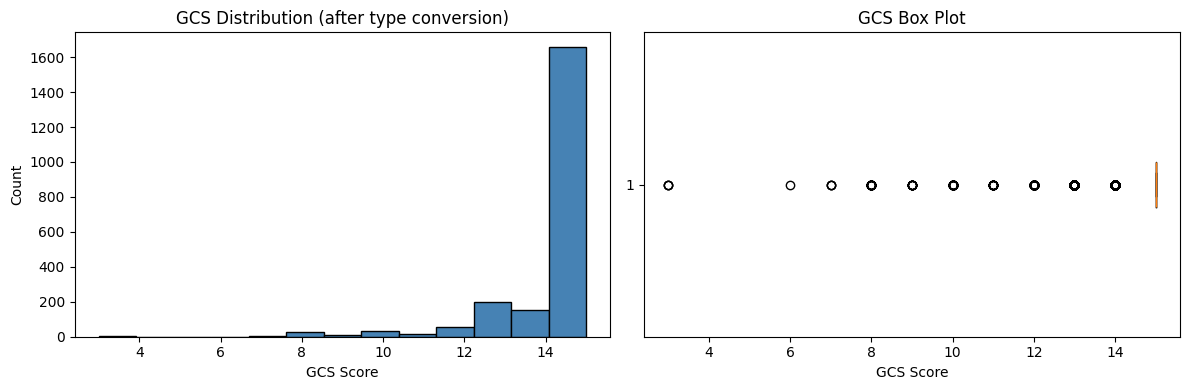

Plot saved as gcs_distribution.png


In [ ]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig(FIGS_PATH / "gcs_distribution.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as gcs_distribution.png")

**[TUTOR NOTE — ask before running the next cell]**
"GCS is scored 3 to 15. If you saw a GCS value of 2 or 16 in this column, what would you do?"

Key teaching point: There are three options for outliers:
1. **Remove** the row entirely (risky — you lose a real patient)
2. **Replace** with NaN, then impute (common approach)
3. **Cap** at the boundary value (e.g. replace 16 with 15)

Which you choose must be *clinically justified*, not just technically convenient.


In [ ]:
# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


In [ ]:
# Step 3: Replace invalid values with NaN
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")

NaN count after range filter: 44


## 5. Imputation — Filling Missing Values

**[TUTOR NOTE — explain the three options before coding, ~5 min]**

Three common imputation strategies:

| Strategy | Use when | Risk |
|----------|----------|------|
| **Mean** | Data is normally distributed, no extreme outliers | Sensitive to outliers — pulls the mean |
| **Median** | Data is skewed or has outliers | More robust, but loses distributional info |
| **Mode** | Categorical or count data | Only works if one value dominates |

For GCS (scored 3–15, skewed toward 15 in most ED populations), the **median** is usually the safer choice.


In [ ]:
# Compute the median and use it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")

GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


**[TUTOR NOTE — walk through this at pace, ~10 min, as the template groups will follow for their columns]**


## 7. Temperature — A Special Case

**[TUTOR NOTE — this is a great teaching moment about unit inconsistency, ~10 min]**
The `Temp` column has a mix of values: some are plain numbers (Celsius), some have a `'C'` suffix, and some were entered in Fahrenheit.
This is a unit inconsistency error — one of the most common data quality issues in clinical datasets.


In [ ]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


In [ ]:
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [ ]:
# Apply range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0


## 8. Breakout Groups — Your Column

**[TUTOR NOTE — group assignment, ~30 min]**

Assign each group one column from the list below.
Groups should follow the same pattern demonstrated above:
1. Inspect (`unique()`, `value_counts()`, `describe()`)
2. Understand the clinical meaning and valid range
3. Convert type with `pd.to_numeric(..., errors='coerce')`
4. Flag and replace out-of-range values with NaN
5. Choose and justify an imputation method
6. Document every decision in a comment

**Group assignments:**

| Group | Column | Valid Range | Notes |
|-------|--------|-------------|-------|
| A | `DBP` | 30–150 mmHg | Lower number in blood pressure reading |
| B | `pulse` | 20–250 bpm | Resting adult: 60–100 |
| C | `RR` | 5–60 breaths/min | Resting adult: 12–20 |
| D | `Fio2` | 21–100 % | Room air = 21%. 100% = ventilator. Not an outlier! |
| E | `MAP` | 40–180 mmHg | Calculated: (SBP + 2×DBP) / 3. Cross-validate against formula. |

After the breakout, each group presents their approach to the full cohort (2 minutes each).


#  **MAP Cleaning — SBP and DBP**

### **Preparing SBP for MAP Cleaning**

SBP is the peak pressure in the arteries when the heart beats — the top
number in a reading like 120/80. It is one of the fastest triage signals
for identifying a patient in danger. An SBP below 90 mmHg indicates
hypotension; below 70 mmHg suggests the patient may be in shock.

**Cleaning decisions:**
The column was stored as strings (object dtype), requiring conversion to
numeric before any analysis could be done. 44 values of 30 and 500 were
identified — these are data entry errors, not outliers. A real SBP of 30
is not survivable outside a resuscitation bay, and 500 exceeds what human
vasculature can physically generate. These were replaced with NaN.

After removing the invalid values, the distribution was approximately
normal (mean 126.68, median 125.00 — difference of 1.68 mmHg), so we
imputed with the **mean**.

In [57]:
# SBP = Systolic Blood Pressure. Valid range: 50–250 mmHg.
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)

SBP unique values (sample): [ 93. 130. 163. 100. 150. 120. 110. 153. 152. 186. 107.  80.  75.  58.
 140.]
SBP dtype: float64


In [ ]:
# 1. Convert to numeric — non-numeric entries become NaN
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())

After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


In [ ]:
# 2. Identify out-of-range values
invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())

Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0


In [ ]:
# 3. Replace out-of-range with NaN, then impute with median
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")

SBP after cleaning: min=55.0, max=250.0, NaNs=0


### **Preparing DBP for MAP Cleaning**

Since the assigned column is `MAP`, we first prepared `DBP` because MAP is calculated using both systolic and diastolic blood pressure. `DBP` stands for diastolic blood pressure, which is the lower number in a blood pressure reading.

The valid DBP range used for this task is `30-150 mmHg`. Values outside this range were treated as invalid and converted to `NaN` so they would not be used directly in the MAP calculation.

After invalid and missing DBP values were identified, I used **median imputation** to fill the missing DBP entries. The median was selected because blood pressure values can contain outliers, and the median is less affected by extreme values than the mean. This allowed the DBP column to remain usable for the later MAP calculation while reducing the influence of unusually high or low values.

In [ ]:
# Cleaning DBP as preparation for MAP calculation

# Inspecting DBP before cleaning
print("DBP dtype:", df["DBP"].dtype)
print("DBP unique values sample:", df["DBP"].unique()[:20])
print("DBP missing values before cleaning:", df["DBP"].isnull().sum())

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [ ]:
# Converting DBP to numeric
df["DBP"] = pd.to_numeric(df["DBP"], errors="coerce")

print("\nDBP dtype after conversion:", df["DBP"].dtype)
print("DBP missing values after conversion:", df["DBP"].isnull().sum())

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [ ]:
# Flagging invalid DBP values
# Valid DBP range: 30-150 mmHg
invalid_dbp = df[(df["DBP"] < 30) | (df["DBP"] > 150)]

print(f"\nDBP values outside valid range (30-150): {len(invalid_dbp)} rows")
print(invalid_dbp[["ID", "DBP"]].head(10))

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [ ]:
# Replacing invalid DBP values with NaN
df.loc[(df["DBP"] < 30) | (df["DBP"] > 150), "DBP"] = np.nan

print("\nDBP missing values after range filtering:", df["DBP"].isnull().sum())

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [ ]:
# Imputing missing DBP values using the median
# Median is used because blood pressure values can contain outliers,
# and the median is less affected by extreme values than the mean.

dbp_median = df["DBP"].median()

df["DBP"] = df["DBP"].fillna(dbp_median)

print(f"\nMedian DBP used for imputation: {dbp_median}")
print("DBP missing values after median imputation:", df["DBP"].isnull().sum())

print("\nDBP summary after imputation:")
print(df["DBP"].describe())

print("DBP missing values after range filtering:", df["DBP"].isnull().sum())

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


### **Finalising MAP Cleaning**

MAP represents the average pressure driving blood to organs across a full cardiac cycle. A healthy MAP is typical within the range of 70 to 100 mmHg, and a map below that is a clinical threshold for organ hypoperfusion.

How do we calculate MAP?/Why we recalculate instead of using the filter?
MAP is not directly measured — it is calculated from the (above) SBP and DBP rating:

MAP = (SBP + 2 * DBP) /3

Before cleaning, 43 rows had MAP values that didn't match the formula, because MAP had been computed from the dirty SBP data. Simple filtration would leave those "silently" wrong values in place. However, recalculating from the cleaness SBP and DBP guarantees consistency/correctness.

In [ ]:
# Recalculate MAP from cleaned SBP and DBP instead of filtering the existing column
# — 43 rows had MAP corrupted by dirty SBP values before cleaning
df['MAP'] = ((df['SBP'] + 2 * df['DBP']) / 3).round(2)

print('MAP after recalculation:')
print(df['MAP'].describe())

MAP after recalculation:
count    2205.000000
mean       93.787079
std        18.547074
min        39.330000
25%        83.330000
50%        93.330000
75%       103.330000
max       173.330000
Name: MAP, dtype: float64


In [ ]:
out_of_range_map = df[(df['MAP'] < 40) | (df['MAP'] > 180)]
print(f'MAP values outside 40–180 mmHg: {len(out_of_range_map)}')

if not out_of_range_map.empty:
    print(out_of_range_map[['ID', 'SBP', 'DBP', 'MAP']])
    print()
    print('Both SBP and DBP are within valid ranges — this is a critically ill')
    print('patient (severe hypotension), not a data error. Preserved intentionally.')

MAP values outside 40–180 mmHg: 1
        ID   SBP   DBP    MAP
1710  1762  58.0  30.0  39.33

Both SBP and DBP are within valid ranges — this is a critically ill
patient (severe hypotension), not a data error. Preserved intentionally.


In [ ]:
map_median = df['MAP'].median()
df['MAP'] = df['MAP'].fillna(map_median)

print(f'MAP NaNs after fallback imputation: {df["MAP"].isnull().sum()}')
print(f'Imputed with mean: {map_median:.2f} mmHg')

MAP NaNs after fallback imputation: 0
Imputed with mean: 93.33 mmHg


### **Final Sanity Check**

As to check that the values are consistent and correctly imputated.

In [ ]:
checks = [('SBP', 50, 250), ('DBP', 30, 150), ('MAP', 40, 180)]

for col, lo, hi in checks:
    n_invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    n_null    = df[col].isnull().sum()
    flag = '✓' if (n_invalid == 0 and n_null == 0) else '⚠'
    print(f'{flag} {col}: range {df[col].min():.1f}–{df[col].max():.1f} | '
          f'out-of-range: {n_invalid} | NaNs: {n_null}')

✓ SBP: range 55.0–250.0 | out-of-range: 0 | NaNs: 0
✓ DBP: range 30.0–150.0 | out-of-range: 0 | NaNs: 0
⚠ MAP: range 39.3–173.3 | out-of-range: 1 | NaNs: 0


### **Export**

Just to export the new data into a clean csv from the dirty csv.

In [ ]:
OUTPUT_PATH = 'Emergency_Triage_Dataset_Day2_MAP — Shari, Gabrielle, Asharah, & Josiah.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved → {OUTPUT_PATH}')

Saved → Emergency_Triage_Dataset_Day2_MAP — Shari, Gabrielle, Asharah, & Josiah.csv


## 9. Submission Reminder

**Day 2 Deliverable:**
- Your group's cleaning notebook for your assigned column
- Must include comments explaining *why* you chose each cleaning decision
- Push to your `carisurg-portfolio` GitHub repo
- Share a screenshot on Discord

**Tomorrow (Day 3):** Data visualisation — we will plot the cleaned data to understand what it looks like.

---
### Today's Key Concepts

| Concept | Code |
|---------|------|
| Convert to numeric | `pd.to_numeric(df['col'], errors='coerce')` |
| Find NaNs | `df['col'].isnull().sum()` |
| Fill NaNs with median | `df['col'].fillna(df['col'].median())` |
| Flag outliers | `df[(df['col'] < MIN) \| (df['col'] > MAX)]` |
| Replace outliers | `df.loc[condition, 'col'] = np.nan` |
